#### Loan Default Prediction Model using Deep Learning

#### Objective:
The main aim is to build a model that can predict if a person will default on a loan based on their financial and personal details. This helps banks make smarter and safer lending decisions.

 #### Kaggle Link: https://www.kaggle.com/datasets/nikhil1e9/loan-default

#### Step 1: Import Libraries

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import confusion_matrix, classification_report


#### Step 2: Load the Dataset

In [40]:
data = pd.read_csv(r"C:\Users\NSTIW\Desktop\padmavathik_ NSTI1\datasets\Loan_default.csv") 
data

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0


In [42]:
data.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')

In [93]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 16 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Age             255347 non-null  int64  
 1   LoanAmount      255347 non-null  int64  
 2   CreditScore     255347 non-null  int64  
 3   MonthsEmployed  255347 non-null  int64  
 4   NumCreditLines  255347 non-null  int64  
 5   InterestRate    255347 non-null  float64
 6   LoanTerm        255347 non-null  int64  
 7   DTIRatio        255347 non-null  float64
 8   Education       255347 non-null  int64  
 9   EmploymentType  255347 non-null  int64  
 10  MaritalStatus   255347 non-null  int64  
 11  HasMortgage     255347 non-null  int64  
 12  HasDependents   255347 non-null  int64  
 13  LoanPurpose     255347 non-null  int64  
 14  HasCoSigner     255347 non-null  int64  
 15  Default         255347 non-null  int64  
dtypes: float64(2), int64(14)
memory usage: 31.2 MB


In [95]:
data.describe()

,Age,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,1.494421,1.500096,0.999918,0.500014,0.500268,2.000501,0.500108,0.116128
std,14.990258,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,1.118826,1.117358,0.816051,0.500001,0.500001,1.412723,0.500001,0.320379
min,18.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31.000000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,43.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,0.000000
75%,56.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,2.000000,2.000000,2.000000,1.000000,1.000000,3.000000,1.000000,0.000000
max,69.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,3.000000,3.000000,2.000000,1.000000,1.000000,4.000000,1.000000,1.000000


#### Step 3: Data Exploration

Missing values:
 LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64


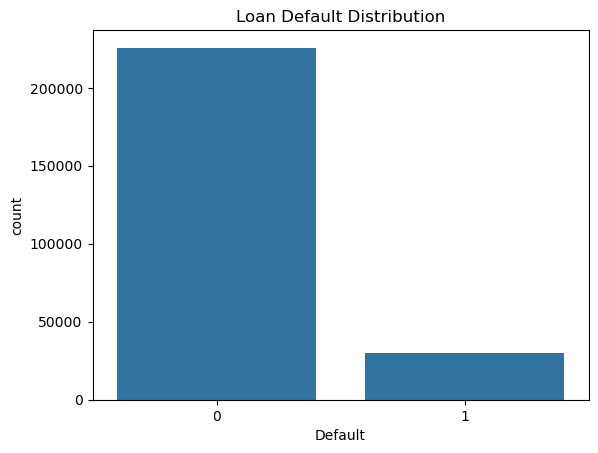

In [44]:
# Check for missing values
print("Missing values:\n", data.isnull().sum())

# Plot target distribution
sns.countplot(x='Default', data=data)
plt.title("Loan Default Distribution")
plt.show()


#### Step 4: Data Preprocessing

In [50]:
data.drop(columns=['Income'], inplace=True)

 #### Step 5: Handle missing values

In [52]:
# Numeric columns 
num_cols = data.select_dtypes(include=['number']).columns
data[num_cols] = data[num_cols].fillna(data[num_cols].mean())

# Categorical columns 
cat_cols = data.select_dtypes(include=['object']).columns
data[cat_cols] = data[cat_cols].fillna('Unknown')


#### Step 6 Encode categorical columns

In [54]:
le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col])


#### Step 7: Split Features and Target

In [58]:
X = data.drop('Default', axis=1)
y = data['Default']


#### Step 8: Scale Features

In [60]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


#### Step 7: Train-Test Split

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


#### Step 9: Build and Train Deep Learning Model

In [64]:
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/20


C:\Users\NSTIW\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6384/6384 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.8791 - loss: 0.3385 - val_accuracy: 0.8846 - val_loss: 0.3205
Epoch 2/20
6384/6384 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - accuracy: 0.8839 - loss: 0.3241 - val_accuracy: 0.8844 - val_loss: 0.3205
Epoch 3/20
6384/6384 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.8835 - loss: 0.3243 - val_accuracy: 0.8845 - val_loss: 0.3200
Epoch 4/20
6384/6384 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.8833 - loss: 0.3246 - val_accuracy: 0.8845 - val_loss: 0.3212
Epoch 5/20
6384/6384 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.8842 - loss: 0.3220 - val_accuracy: 0.8845 - val_loss: 0.3203
Epoch 6/20
6384/6384 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.8837 - loss: 0.3221 - val_accuracy: 0.8840 - val_loss: 0.3206
Epoch 7/20
6384/6384 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - accuracy: 0.8854 - loss: 0.3206 - val_accuracy: 0.8847 - val_loss: 0.3202
Epoch 8/20
6384/6384 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step - accuracy: 0.8837 - loss: 0.3233 - val

#### Step 10: Visulizations

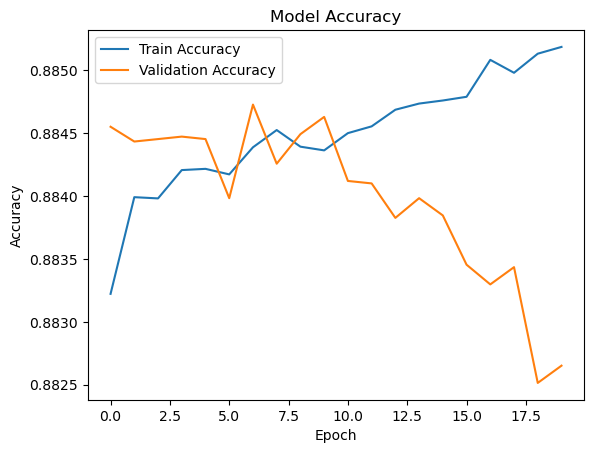

In [77]:
# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

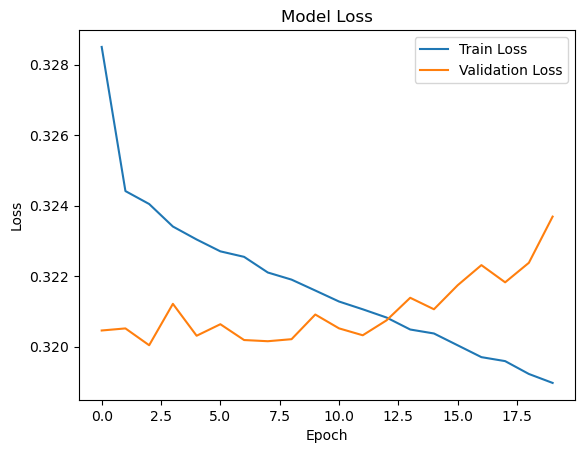

In [79]:
# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

#### Step 11: Evaluate the Model

In [85]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")


1596/1596 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8851 - loss: 0.3213
Test Accuracy: 88.27%


#### Step 12: Confusion Matrix & Classification Report

In [88]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


1596/1596 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
[[44830   340]
 [ 5653   247]]
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45170
           1       0.42      0.04      0.08      5900

    accuracy                           0.88     51070
   macro avg       0.65      0.52      0.51     51070
weighted avg       0.83      0.88      0.84     51070

